In [1]:
import pandas as pd
from matplotlib import lines
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from pygments.lexers import rego

import ltatools as lta

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
    #'font.size' : 13
})

FIGSIZE_TIMESERIES = (9, 4)
FIGSIZE_ADEV = (7, 4)
FIGSIZE_HIST = (7, 4)
FIGSIZE_ADEV_POWER = (7, 3)

# Pre modification (24.06.2026)

10.277587388622344
10.09424436216762


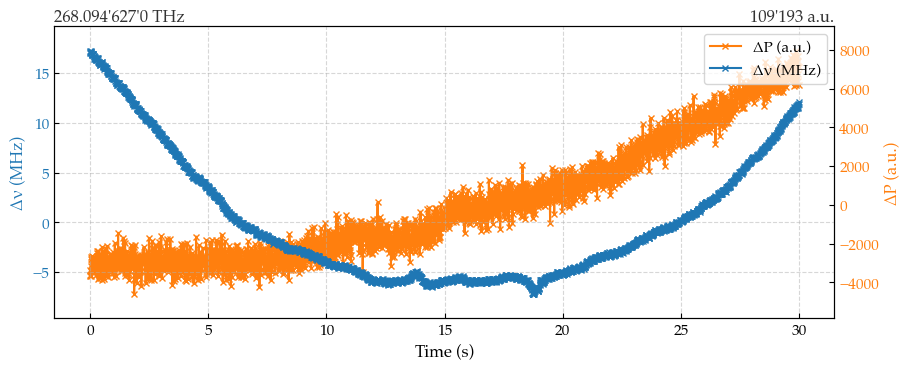

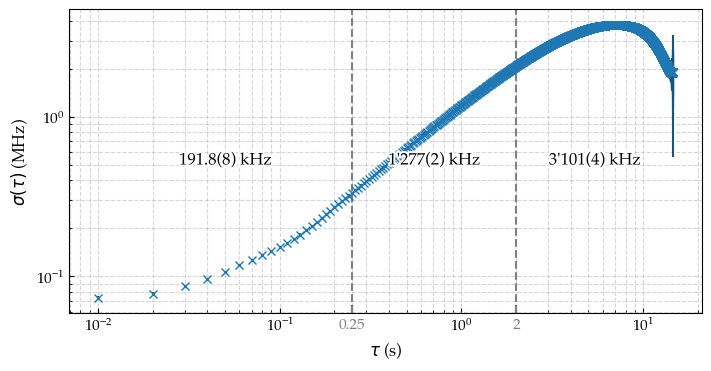

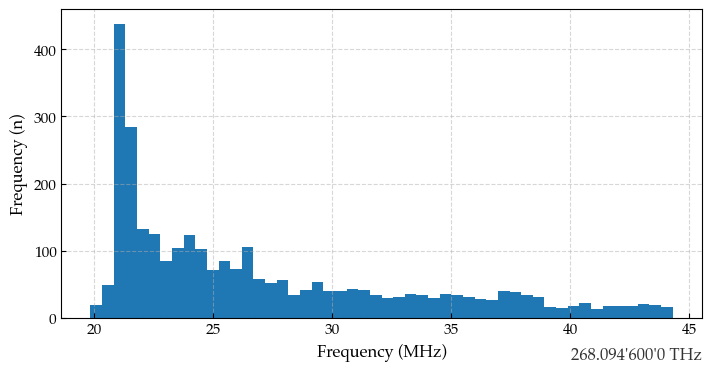

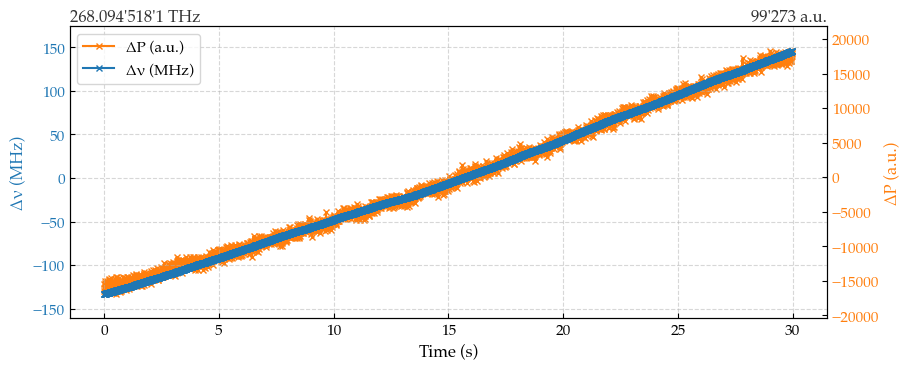

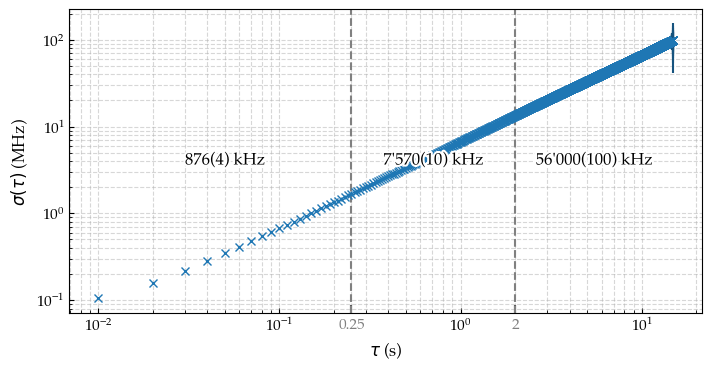

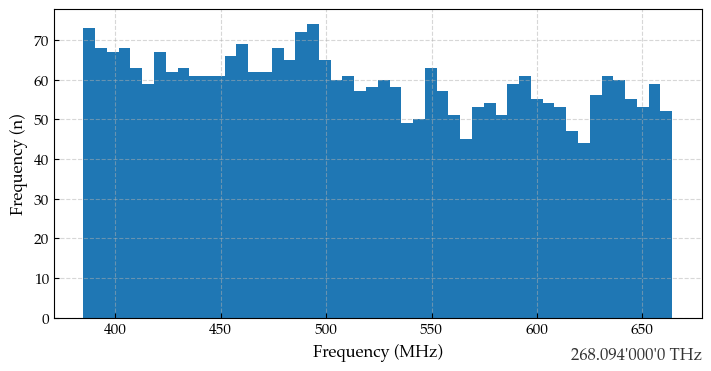

In [10]:
df_pre_2 = lta.load_lta_file('data/24.06.2026, 14.08,  268,0946227 THz.lta', cleanup=True)
df_pre_3 = lta.load_lta_file('data/24.06.2026, 14.33,  268,0950613 THz.lta', cleanup=True)

seg_1 = None
seg_2 = None

for i, seg in enumerate(lta.find_stable_segments(df_pre_2, n=1)):

    label = 'PreMod_LoBound'

    seg = seg[(seg['time_s'] > 32) & (seg['time_s'] < 62)].reset_index(drop=True)

    seg['time_s'] -= seg['time_s'].iloc[0]
    seg['time_ms'] -= seg['time_ms'].iloc[0]

    gate_time = np.mean(seg['time_ms'].diff())
    print(gate_time)

    seg_1 = seg

    #lta.overview_figure(seg, freq_unit='MHz', save=f'fig/overview_{label}.pdf', lines=True, errorbars=False, taus='decade')
    lta.plot(seg, kind='timeseries', lines=True, save=f'fig/timeseries_{label}.pdf', freq_unit='MHz', relative=True, figsize=FIGSIZE_TIMESERIES, label='', tick_direction='in')
    lta.plot(seg, kind='adev', quantity='frequency', errorbars=True, unit='MHz', regions=True, save=f'fig/adev_{label}.pdf', taus='all', figsize=FIGSIZE_ADEV, label='')
    lta.plot(seg, kind='hist', quantity='frequency', save=f'fig/hist_{label}.pdf', unit='MHz', figsize=FIGSIZE_HIST, label='')

for i, seg in enumerate(lta.find_stable_segments(df_pre_3, n=1)):

    label = 'PreMod_Standard'

    seg = seg[(seg['time_s'] > 5) & (seg['time_s'] < 35)].reset_index(drop=True)

    seg['time_s'] -= seg['time_s'].iloc[0]
    seg['time_ms'] -= seg['time_ms'].iloc[0]

    gate_time = np.mean(seg['time_ms'].diff())
    print(gate_time)

    seg_2 = seg

    #lta.overview_figure(seg, freq_unit='MHz', save=f'fig/overview_{label}.pdf', lines=True, errorbars=False)
    lta.plot(seg, kind='timeseries', lines=True, save=f'fig/timeseries_{label}.pdf', freq_unit='MHz', relative=True, figsize=FIGSIZE_TIMESERIES, label='')
    lta.plot(seg, kind='adev', quantity='frequency', errorbars=True, unit='MHz', regions=True, save=f'fig/adev_{label}.pdf', taus='all', figsize=FIGSIZE_ADEV, label='')
    lta.plot(seg, kind='hist', quantity='frequency', save=f'fig/hist_{label}.pdf', unit='MHz', figsize=FIGSIZE_HIST, label='')

# Post modification (02.07.2026 - 03.07.2026) 'NO SOUND ISOLATION'

15.65691906005222


,time_ms,wavelength_nm,power_uW,time_s,frequency_THz
count,1916.000000,1916.000000,1916.000000,1916.000000,1916.000000
mean,14676.852818,1118.228156,142103.113857,14.676853,268.095966
std,8655.445967,0.000020,865.504530,8.655446,0.000005
min,0.000000,1118.228116,139641.090000,0.000000,268.095959
25%,7174.500000,1118.228146,141492.345000,7.174500,268.095963
50%,14488.500000,1118.228159,142091.190000,14.488500,268.095965
75%,22081.000000,1118.228171,142702.087500,22.081000,268.095969
max,29983.000000,1118.228187,145131.000000,29.983000,268.095976


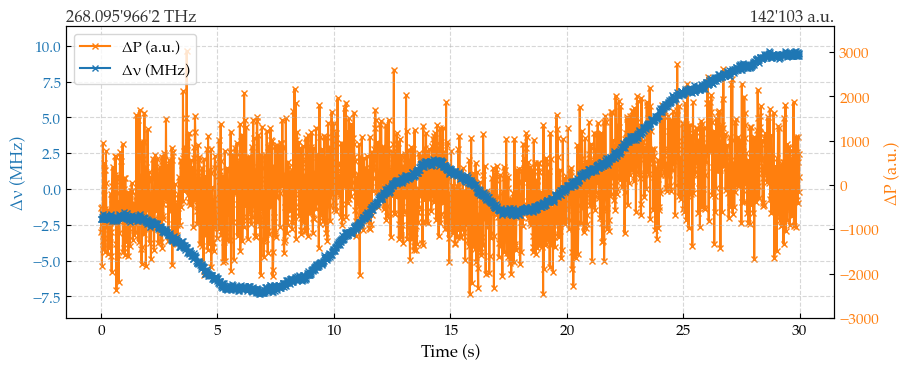

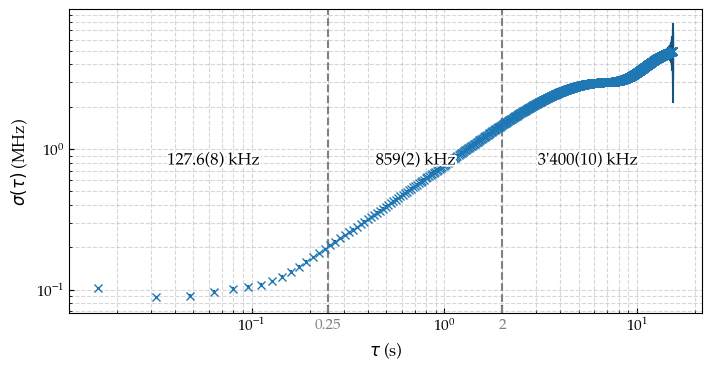

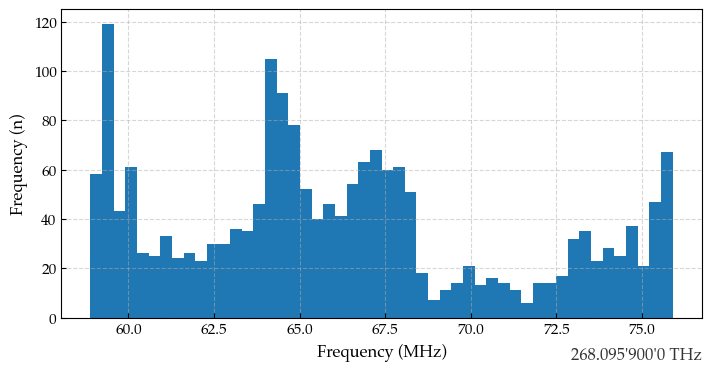

In [3]:
df_post_ni_1 = lta.load_lta_file('data/02.07.2026, 19.15,  268,0959664 THz.lta', cleanup=False)
#df_post_ni_2 = lta.load_lta_file('data/03.07.2026, 17.05,  268,0983027 THz.lta', cleanup=False)

label_post_ni = 'PostMod_noIso'

df_post_ni_1 = df_post_ni_1[(df_post_ni_1['time_s'] > 30) & (df_post_ni_1['time_s'] < 60)].reset_index(drop=True)

df_post_ni_1['time_s'] -= df_post_ni_1['time_s'].iloc[0]
df_post_ni_1['time_ms'] -= df_post_ni_1['time_ms'].iloc[0]

gate_time_ni = np.mean(df_post_ni_1['time_ms'].diff())
print(gate_time_ni)

#_, _ = lta.overview_figure(df_post_ni_1, freq_unit='MHz', save=f'fig/overview_02-07_19-15.pdf', lines=True, errorbars=False)
#lta.overview_figure(df_post_ni_2, freq_unit='MHz', save=f'fig/overview_03-07_17-05.pdf', lines=True)
#lta.plot(data=df_post_ni_1, kind='overview', lines=True, save=f'fig/overview_{label_post_ni}.pdf')
lta.plot(data=df_post_ni_1, kind='timeseries', lines=True, save=f'fig/timeseries_{label_post_ni}.pdf', relative=True, freq_unit='MHz', figsize=FIGSIZE_TIMESERIES, label='')
lta.plot(data=df_post_ni_1, kind='adev', quantity='frequency', errorbars=True, unit='MHz', regions=True, save=f'fig/adev_{label_post_ni}.pdf', figsize=FIGSIZE_ADEV, label='')
lta.plot(data=df_post_ni_1, kind='hist', quantity='frequency', save=f'fig/hist_{label_post_ni}.pdf', unit='MHz', figsize=FIGSIZE_HIST, label='')

#lta.plot(data=df_post_ni_1, kind='adev', quantity='power', errorbars=True, unit='a.u.', save=f'fig/adev_power_{label_post_ni}.pdf', figsize=FIGSIZE_ADEV_POWER, label='', regions=True)

df_post_ni_1.describe()

# Post modification (06.07.2026) 'SOUND ISOLATION'

12.442092154420921


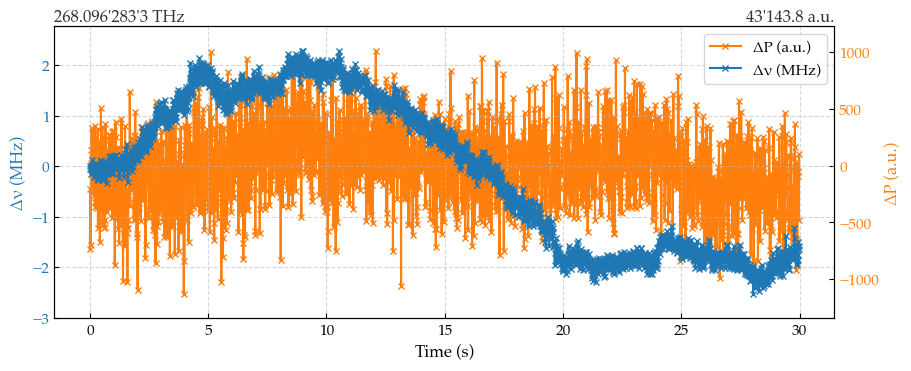

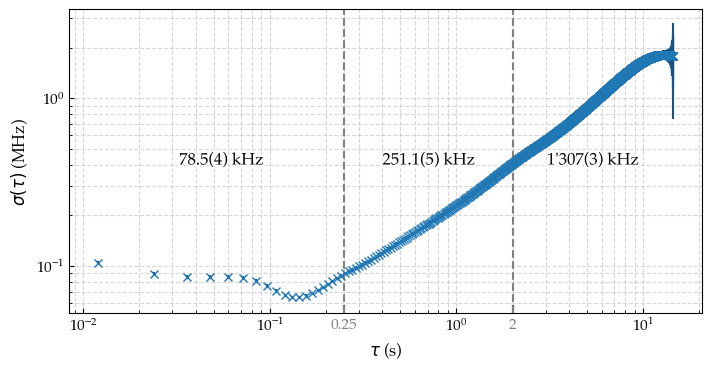

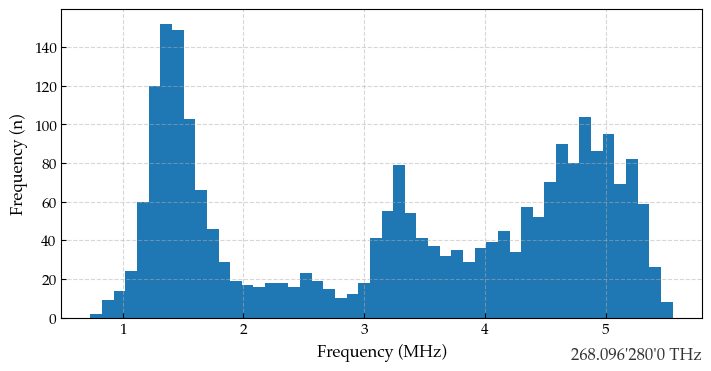

In [4]:
df_post_si_3 = lta.load_lta_file('data/06.07.2026, 15.12,  268,0962819 THz.lta', cleanup=False)

label_post_si = 'PostMod_Iso'

df_post_si_3 = df_post_si_3[(df_post_si_3['time_s'] > 0) & (df_post_si_3['time_s'] < 30)].reset_index(drop=True)

df_post_si_3['time_s'] -= df_post_si_3['time_s'].iloc[0]
df_post_si_3['time_ms'] -= df_post_si_3['time_ms'].iloc[0]

gate_time_si = np.mean(df_post_si_3['time_ms'].diff())
print(gate_time_si)

lta.plot(data=df_post_si_3, kind='timeseries', lines=True, save=f'fig/timeseries_{label_post_si}.pdf', relative=True, freq_unit='MHz', figsize=FIGSIZE_TIMESERIES, label='')
lta.plot(data=df_post_si_3, kind='adev', quantity='frequency', errorbars=True, unit='MHz', save=f'fig/adev_{label_post_si}.pdf', regions=True, figsize=FIGSIZE_ADEV, label='')
lta.plot(data=df_post_si_3, kind='hist', quantity='frequency', save=f'fig/hist_{label_post_si}.pdf', unit='MHz', figsize=FIGSIZE_HIST, label='')

#lta.plot(data=df_post_si_3, kind='adev', quantity='power', errorbars=True, unit='a.u.', save=f'fig/adev_power_{label_post_si}.pdf', figsize=FIGSIZE_ADEV_POWER, label='', regions=True)

# PSD of the frequency data for the different scenarios

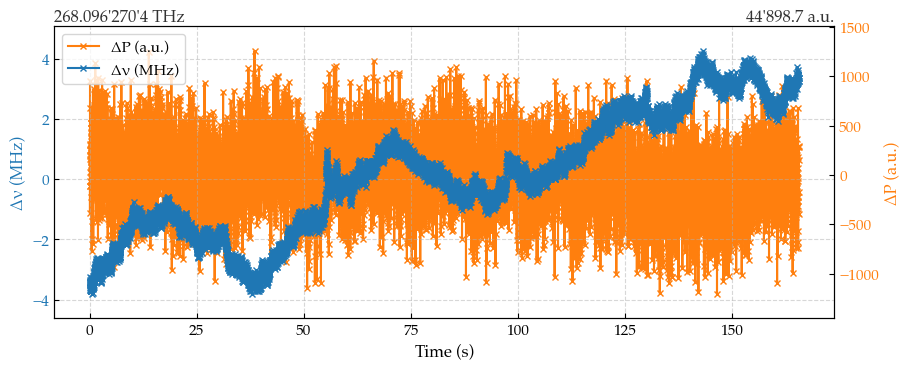

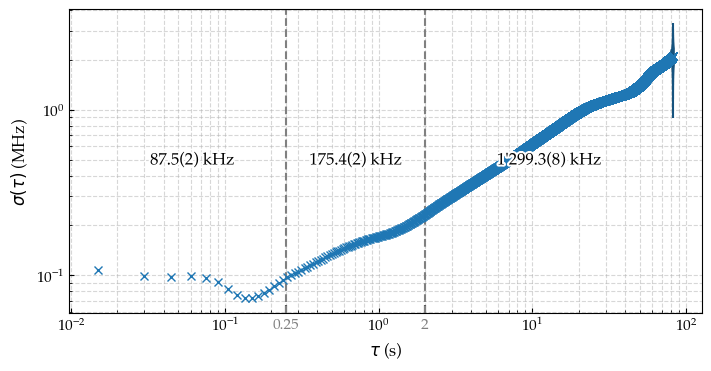

In [5]:
df_sriram = lta.load_lta_file('data/07.07.2026, 19.56,  268,0223923 v4THz.lta', cleanup=False)
df_post_si_long = lta.load_lta_file('data/06.07.2026, 14.55,  268,0962734 THz.lta', cleanup=False)

df_sriram = df_sriram[(df_sriram['time_s'] > 250) & (df_sriram['time_s'] < 2000)].reset_index(drop=True)

lta.plot(data=df_post_si_long, kind='timeseries', lines=True,  relative=True, freq_unit='MHz', figsize=FIGSIZE_TIMESERIES, label='')
lta.plot(data=df_post_si_long, kind='adev', quantity='frequency', errorbars=True, unit='MHz', regions=True, figsize=FIGSIZE_ADEV, label='')

#lta.plot(data=df_sriram, kind='timeseries', lines=True,  relative=True, freq_unit='MHz', figsize=FIGSIZE_TIMESERIES, label='')
#lta.plot(data=df_sriram, kind='adev', quantity='frequency', errorbars=True, unit='MHz', regions=True, figsize=FIGSIZE_ADEV, label='')

/var/folders/y8/mwx0bxn57c58pqv1hvn3fxm00000gn/T/ipykernel_3803/156745038.py:44: UserWarning: Timestamps are irregularly spaced (max relative jitter 140.00% exceeds tolerance 1.00%); Welch's method assumes uniform sampling.
  f, Pxx = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'])
/var/folders/y8/mwx0bxn57c58pqv1hvn3fxm00000gn/T/ipykernel_3803/156745038.py:55: UserWarning: Timestamps are irregularly spaced (max relative jitter 140.00% exceeds tolerance 1.00%); Welch's method assumes uniform sampling.
  _, Pxx_lin = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'],
/var/folders/y8/mwx0bxn57c58pqv1hvn3fxm00000gn/T/ipykernel_3803/156745038.py:44: UserWarning: Timestamps are irregularly spaced (max relative jitter 60.00% exceeds tolerance 1.00%); Welch's method assumes uniform sampling.
  f, Pxx = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'])
/var/folders/y8/mwx0bxn57c58pqv1hvn3fxm00000gn/T/ipykernel_3803/156745038.py:55: UserWarning: Tim

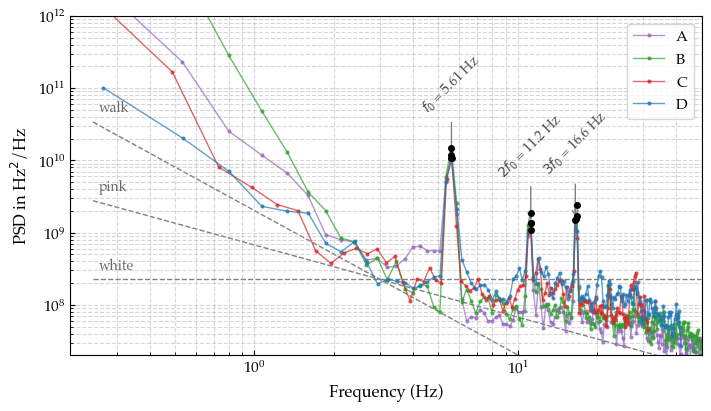

      f0 (Hz)                   lines (Hz)  family rms  rms const  rms linear
A      5.6000           5.60  11.20  16.80      81.2 kHz    638.3 kHz     241.3 kHz
B      5.6000           5.60  11.20  16.80      91.4 kHz   3593.4 kHz     239.7 kHz
C      5.6152           5.62  11.23  16.60      73.2 kHz    527.2 kHz     234.3 kHz
D      5.6090           5.61  11.22  16.56      77.3 kHz    185.6 kHz     152.2 kHz


In [13]:
FIGSIZE_PSD = (7, 4)

# Frequency-noise PSD of the three scenarios (frequency column is THz -> Hz).
psd_sets = [
    #(df_post_si_long, 'D long', 'tab:cyan'),
    (seg_1, 'A', 'tab:purple'),
    (seg_2, 'B', 'tab:green'),
    (df_post_ni_1, 'C', 'tab:red'),
    (df_post_si_3, 'D', 'tab:blue'),
    #(df_sriram, 'E', 'tab:orange')
]

PROM = 3e8          # prominence / height threshold for the peak search, Hz^2/Hz
F_MIN_PEAK = 1.0    # ignore the drift-dominated bins below this


def spectral_peaks(f, Pxx, f_min=F_MIN_PEAK, prominence=PROM, height=PROM):
    """Return (frequencies, PSD) of the peaks above `f_min`.

    find_peaks must see a CONTIGUOUS slice of the spectrum. Masking on
    amplitude as well (``Pxx > x``) leaves an array whose neighbouring samples
    are not neighbouring frequencies, which corrupts both the peak detection
    and the prominence. The amplitude cut belongs in `height`, not in a mask.
    """
    sl = f > f_min
    idx, _ = sp.signal.find_peaks(Pxx[sl], prominence=prominence, height=height)
    return f[sl][idx], Pxx[sl][idx]          # frequencies -- NOT indices


def line_rms(f, Pxx, f_c, half_width=0.9, gap=1.3, span=3.0):
    """RMS of the line at `f_c` in excess of the local broadband baseline, in Hz."""
    band = (f > f_c - half_width) & (f < f_c + half_width)
    side = ((f > f_c - span) & (f < f_c - gap)) | ((f > f_c + gap) & (f < f_c + span))
    if not band.any() or not side.any():
        return np.nan
    base = np.median(Pxx[side])
    return np.sqrt(np.trapezoid(np.clip(Pxx[band] - base, 0, None), f[band]))


fig, ax = plt.subplots(figsize=FIGSIZE_PSD, constrained_layout=True)

spectra, summary = [], []
for df, psd_label, color in psd_sets:
    f, Pxx = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'])
    m = f > 0                                    # drop the DC bin for the log axis
    ax.plot(f[m], Pxx[m], color=color, label=psd_label, marker='o', markersize=2,
            linewidth=1, alpha=0.7)
    spectra.append((f[m], Pxx[m]))

    if psd_label != 'E':
        f_pk, P_pk = spectral_peaks(f, Pxx)
        ax.plot(f_pk, P_pk, 'o', markersize=4, color='k', zorder=5)

        # linear detrend: removes the drift so the broadband noise is visible
        _, Pxx_lin = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'],
                                     detrend='linear')

        summary.append((psd_label, f_pk,
                        [line_rms(f, Pxx, fc) for fc in f_pk],
                        np.sqrt(np.trapezoid(Pxx[m], f[m])),
                        np.sqrt(np.trapezoid(Pxx_lin[m], f[m]))))

# Annotate the harmonic family once, from the D spectrum (the final scenario).
f_pk_D, P_pk_D = spectral_peaks(*lta.compute_psd(df_post_si_3['frequency_THz'] * 1e12,
                                                 time_s=df_post_si_3['time_s']))
f0 = f_pk_D[0]
for n, (fc, Pc) in enumerate(zip(f_pk_D, P_pk_D), start=1):
    tag = rf'$f_0$ = {fc:.2f} Hz' if n == 1 else rf'${n}f_0$ = {fc:.1f} Hz'
    ax.annotate(tag, xy=(fc, Pc), xytext=(0, 30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='0.5'), color='0.3',
                rotation=45, ha='center', va='bottom', fontsize=10)

ax.set_xscale('log')
ax.set_yscale('log')

# Power-law slope GUIDES (not fits): anchored to the median of the D spectrum
# between 2 and 4 Hz, where no line and no drift skirt sits.
f_all = np.concatenate([s[0] for s in spectra])
f_guide = np.geomspace(f_all.min(), f_all.max(), 200)
fD, PD = spectra[-1]
anchor_band = (fD > 2) & (fD < 4)
f_anchor, P_anchor = 3.0, np.median(PD[anchor_band])
for slope, name in ((0, 'white'), (-1, 'pink'), (-2, 'walk')):
    y_guide = P_anchor * (f_guide / f_anchor) ** slope
    ax.plot(f_guide, y_guide, color='0.5', ls='--', lw=1, zorder=0)
    inside = np.flatnonzero((y_guide > 4e7) & (y_guide < 2.5e11))
    if inside.size:
        ax.annotate(name, xy=(f_guide[inside[0]], y_guide[inside[0]]), xytext=(4, 4),
                    textcoords='offset points', color='0.4', fontsize=10,
                    ha='left', va='bottom')

ax.set_xlim(0.2, 50)
ax.set_ylim(2e7, 1e12)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'PSD in Hz$^2$/Hz')
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.tick_params(axis='both', direction='in')
ax.legend(loc='upper right')

fig.savefig('fig/psd_comparison.pdf', dpi=600)
plt.show()

# ---------------------------------------------------------------------------
# Numeric summary. The mean-only detrend leaves a linear drift in the data, so
# the lowest bins of the plot above show the DRIFT, not the noise; the linear
# detrend column is the like-for-like broadband comparison.
# ---------------------------------------------------------------------------
print(f"{'':3s} {'f0 (Hz)':>9s} {'lines (Hz)':>28s} {'family rms':>11s} "
      f"{'rms const':>10s} {'rms linear':>11s}")
for lab, f_pk, rms_list, rms_const, rms_lin in summary:
    fam = np.sqrt(np.nansum(np.square(rms_list)))
    lines = ' '.join(f'{v:6.2f}' for v in f_pk)
    print(f"{lab:3s} {f_pk[0]:9.4f} {lines:>28s} {fam/1e3:9.1f} kHz "
          f"{rms_const/1e3:8.1f} kHz {rms_lin/1e3:9.1f} kHz")

In [9]:
FIGSIZE_PSD = (7, 4)

# Frequency-noise PSD of the three scenarios (frequency column is THz -> Hz).
psd_sets = [
    #(df_post_si_long, 'D long', 'tab:cyan'),
    (seg_2, 'B', 'tab:green'),
    (df_post_ni_1, 'C', 'tab:red'),
    (df_post_si_3, 'D', 'tab:blue'),
    #(df_sriram, 'V#5', 'tab:orange')
]

PROM = 3e8          # prominence / height threshold for the peak search, Hz^2/Hz
F_MIN_PEAK = 1.0    # ignore the drift-dominated bins below this


def spectral_peaks(f, Pxx, f_min=F_MIN_PEAK, prominence=PROM, height=PROM):
    """Return (frequencies, PSD) of the peaks above `f_min`.

    find_peaks must see a CONTIGUOUS slice of the spectrum. Masking on
    amplitude as well (``Pxx > x``) leaves an array whose neighbouring samples
    are not neighbouring frequencies, which corrupts both the peak detection
    and the prominence. The amplitude cut belongs in `height`, not in a mask.
    """
    sl = f > f_min
    idx, _ = sp.signal.find_peaks(Pxx[sl], prominence=prominence, height=height)
    return f[sl][idx], Pxx[sl][idx]          # frequencies -- NOT indices


def line_rms(f, Pxx, f_c, half_width=0.9, gap=1.3, span=3.0):
    """RMS of the line at `f_c` in excess of the local broadband baseline, in Hz."""
    band = (f > f_c - half_width) & (f < f_c + half_width)
    side = ((f > f_c - span) & (f < f_c - gap)) | ((f > f_c + gap) & (f < f_c + span))
    if not band.any() or not side.any():
        return np.nan
    base = np.median(Pxx[side])
    return np.sqrt(np.trapezoid(np.clip(Pxx[band] - base, 0, None), f[band]))


fig, ax = plt.subplots(figsize=FIGSIZE_PSD, constrained_layout=True)

spectra, summary = [], []
for df, psd_label, color in psd_sets:
    f, Pxx = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'])
    m = f > 0                                    # drop the DC bin for the log axis
    ax.plot(f[m], Pxx[m], color=color, label=psd_label, marker='o', markersize=2,
            linewidth=1, alpha=0.7)
    spectra.append((f[m], Pxx[m]))

    if psd_label != 'V#5':
        f_pk, P_pk = spectral_peaks(f, Pxx)
        #ax.plot(f_pk, P_pk, 'o', markersize=4, color='k', zorder=5)

        # linear detrend: removes the drift so the broadband noise is visible
        _, Pxx_lin = lta.compute_psd(df['frequency_THz'] * 1e12, time_s=df['time_s'],
                                     detrend='linear')

        summary.append((psd_label, f_pk,
                        [line_rms(f, Pxx, fc) for fc in f_pk],
                        np.sqrt(np.trapezoid(Pxx[m], f[m])),
                        np.sqrt(np.trapezoid(Pxx_lin[m], f[m]))))

# Annotate the harmonic family once, from the D spectrum (the final scenario).
f_pk_D, P_pk_D = spectral_peaks(*lta.compute_psd(df_post_si_3['frequency_THz'] * 1e12,
                                                 time_s=df_post_si_3['time_s']))
f0 = f_pk_D[0]
for n, (fc, Pc) in enumerate(zip(f_pk_D, P_pk_D), start=1):
    tag = rf'$f_0$ = {fc:.2f} Hz' if n == 1 else rf'${n}f_0$ = {fc:.1f} Hz'
    ax.annotate(tag, xy=(fc, Pc), xytext=(0, 30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='0.5'), color='0.3',
                rotation=45, ha='center', va='bottom', fontsize=11)

ax.set_xscale('log')
ax.set_yscale('log')

# Power-law slope GUIDES (not fits): anchored to the median of the D spectrum
# between 2 and 4 Hz, where no line and no drift skirt sits.
f_all = np.concatenate([s[0] for s in spectra])
f_guide = np.geomspace(f_all.min(), f_all.max(), 200)
fD, PD = spectra[-1]
anchor_band = (fD > 2) & (fD < 4)
f_anchor, P_anchor = 3.0, np.median(PD[anchor_band])
for slope, name in ((0, 'white'), (-1, 'pink'), (-2, 'walk')):
    y_guide = P_anchor * (f_guide / f_anchor) ** slope
    #ax.plot(f_guide, y_guide, color='0.5', ls='--', lw=1, zorder=0)
    #inside = np.flatnonzero((y_guide > 4e7) & (y_guide < 2.5e11))
    #if inside.size:
        #ax.annotate(name, xy=(f_guide[inside[0]], y_guide[inside[0]]), xytext=(4, 4),
        #            textcoords='offset points', color='0.4', fontsize=10,
        #            ha='left', va='bottom')

ax.set_xlim(0.2, 50)
ax.set_ylim(2e7, 5e13)
ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel(r'PSD in Hz$^2$/Hz', fontsize=13)
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.tick_params(axis='both', direction='in')
ax.legend(loc='upper left')

fig.savefig('fig/psd_comparison_external.pdf', dpi=600)
plt.show()

<>:6: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:6: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
/var/folders/y8/mwx0bxn57c58pqv1hvn3fxm00000gn/T/ipykernel_3803/3336597834.py:6: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  (seg_1, 'A', 'tab:purple')


TypeError: 'tuple' object is not callable

# Removing the 5.56 Hz family from the ADEV of scenario D

  f0: 5.6090 Hz (PSD bin)  ->  5.5565 Hz (residual-minimising)
  1f0 =  5.556 Hz   amplitude   92.5 kHz   rms   65.4 kHz
  2f0 = 11.113 Hz   amplitude   31.6 kHz   rms   22.3 kHz
  3f0 = 16.669 Hz   amplitude   33.4 kHz   rms   23.6 kHz
  family combined rms 73.0 kHz
  rms of the removed component 73.0 kHz (orthogonality check against 73.0 kHz above; the PSD line integral gave 77.3 kHz)


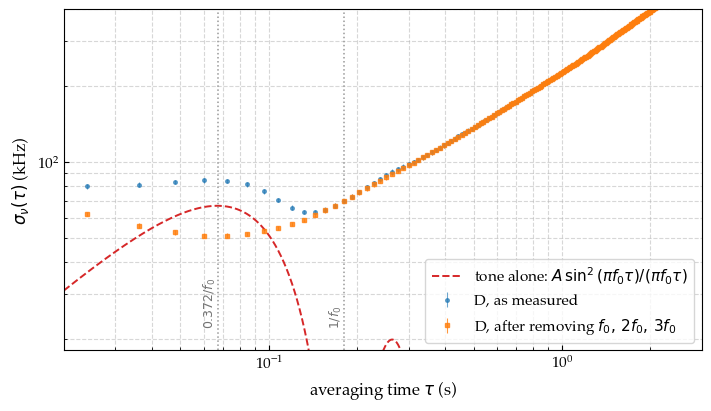


  region mean sigma (tau < 0.25 s): 75.3 kHz -> 63.6 kHz (16 % reduction)
  local max: measured tau = 0.288 s /  95.7 kHz   ->   removed tau = 0.288 s /  94.3 kHz
  local min: measured tau = 0.144 s /  63.2 kHz   ->   removed tau = 0.060 s /  51.1 kHz


In [8]:
FIGSIZE_ADEV_TONE = (7, 4)

# ---------------------------------------------------------------------------
# Does the 5.56 Hz family account for the short-tau ADEV of scenario D?
#
# Model-independent test: fit amplitude and phase of f0, 2f0 and 3f0 on top of
# a quadratic trend, then subtract ONLY the harmonic columns and recompute the
# ADEV. The trend columns are fitted but kept, so the long-tau behaviour is
# untouched and any change at short tau is attributable to the tone alone.
#
# A sinusoid of peak amplitude A contributes
#       sigma(tau) = A sin^2(pi f0 tau) / (pi f0 tau)
# (Riley, NIST SP 1065, where the variance is written 2 A_rms^2 sin^4(x)/x^2 --
# mind the rms-vs-peak convention, it differs by sqrt(2)). Nulls sit at
# tau = n/f0, the first maximum at tau ~ 0.372/f0 where sigma ~ 0.72 A.
# ---------------------------------------------------------------------------

HARMONICS = (1, 2, 3)
df_tone = df_post_si_3

# Both the least-squares fit and oadev want a uniform grid; the wavemeter
# timestamps jitter by far less than one gate time, so interpolation is safe.
t_tone = df_tone['time_s'].to_numpy()
dt_tone = np.median(np.diff(t_tone))
t_u = np.arange(t_tone[0], t_tone[-1], dt_tone)
y = np.interp(t_u, t_tone, df_tone['frequency_THz'].to_numpy() * 1e12)
y = y - y.mean()

def tone_design(f_0):
    """Quadratic trend (columns 0:3, kept) + the harmonic family (3:, removed)."""
    cols = [np.ones_like(t_u), t_u, t_u ** 2]
    for n in HARMONICS:
        cols += [np.cos(2 * np.pi * n * f_0 * t_u),
                 np.sin(2 * np.pi * n * f_0 * t_u)]
    return np.vstack(cols).T


def fit_residual(f_0):
    M_ = tone_design(f_0)
    c_, *_ = np.linalg.lstsq(M_, y, rcond=None)
    return np.sum((y - M_ @ c_) ** 2)


# The PSD bin is far too coarse to fit against: at df = 1/T = 0.03 Hz a
# half-bin error already slips the model half a cycle over the record, and the
# fitted amplitude collapses. Refine f0 by minimising the fit residual instead.
F0_SEED = float(globals().get('f0', 5.556))
f_grid = np.arange(F0_SEED - 0.20, F0_SEED + 0.20, 5e-4)
F0 = float(f_grid[np.argmin([fit_residual(v) for v in f_grid])])
print(f'  f0: {F0_SEED:.4f} Hz (PSD bin)  ->  {F0:.4f} Hz (residual-minimising)')

M = tone_design(F0)
coef, *_ = np.linalg.lstsq(M, y, rcond=None)
tone = M[:, 3:] @ coef[3:]
y_clean = y - tone

amps = {n: float(np.hypot(coef[3 + 2 * i], coef[4 + 2 * i]))
        for i, n in enumerate(HARMONICS)}
# Variances add, not amplitudes: the harmonics sit at different frequencies and
# are therefore orthogonal over a record of many cycles. Cross-checked against
# std(tone) below -- if the two disagreed the quadrature sum would be
# overstating, and the direct std would be the number to trust.
rms_family = np.sqrt(sum(a ** 2 for a in amps.values())) / np.sqrt(2)

# A = sqrt(2) * rms is a PER-LINE identity. No "family amplitude" is printed on
# purpose: the peak excursion of f0 + 2f0 + 3f0 added together depends on their
# relative phases, which the PSD discards, so it is not fixed by the rms values.
for n, a in amps.items():
    print(f'  {n}f0 = {n * F0:6.3f} Hz   amplitude {a / 1e3:6.1f} kHz   '
          f'rms {a / np.sqrt(2) / 1e3:6.1f} kHz')
print(f'  family combined rms {rms_family / 1e3:.1f} kHz')
# Cross-check against the PSD. Comparing rms(y) before and after would say
# nothing -- the total rms is dominated by the drift this test deliberately
# keeps. The statistic that matches the PSD line integral is the rms of the
# REMOVED component itself, which should reproduce the family rms read off
# psd_comparison.pdf (77.3 kHz for D).
print(f'  rms of the removed component {tone.std() / 1e3:.1f} kHz '
      f'(orthogonality check against {rms_family / 1e3:.1f} kHz above; '
      f'the PSD line integral gave 77.3 kHz)')

tau, adev, adev_err, _ = lta.compute_oadev(y, rate=1 / dt_tone, taus='all')
_, adev_c, adev_c_err, _ = lta.compute_oadev(y_clean, rate=1 / dt_tone, taus='all')

tau_fine = np.geomspace(0.02, 3, 3000)
x = np.pi * F0 * tau_fine
tone_curve = amps[1] * np.sin(x) ** 2 / x       # fundamental alone, from the fit

fig, ax = plt.subplots(figsize=FIGSIZE_ADEV_TONE, constrained_layout=True)
ax.errorbar(tau, adev / 1e3, yerr=adev_err / 1e3, fmt='o', markersize=2.6,
            linewidth=0.8, color='tab:blue', alpha=0.65, label='D, as measured')
ax.errorbar(tau, adev_c / 1e3, yerr=adev_c_err / 1e3, fmt='s', markersize=2.6,
            linewidth=0.8, color='tab:orange', alpha=0.8,
            label=r'D, after removing $f_0,\,2f_0,\,3f_0$')
ax.plot(tau_fine, tone_curve / 1e3, '--', color='tab:red', linewidth=1.4,
        label=r'tone alone: $A\,\sin^2(\pi f_0\tau)/(\pi f_0\tau)$')

for x_v, lab in ((0.3724 / F0, r'$0.372/f_0$'), (1 / F0, r'$1/f_0$')):
    ax.axvline(x_v, color='0.6', ls=':', linewidth=1.1)
    ax.annotate(lab, xy=(x_v, 22), rotation=90, color='0.45', fontsize=9,
                ha='right', va='bottom')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.02, 3)
ax.set_ylim(18, 400)
ax.set_xlabel(r'averaging time $\tau$ (s)')
ax.set_ylabel(r'$\sigma_\nu(\tau)$ (kHz)')
ax.grid(True, which='both', ls='--', alpha=0.5)
ax.tick_params(axis='both', direction='in', which='both')
ax.legend(fontsize=11, loc='lower right')

fig.savefig('fig/adev_PostMod_Iso_tone.pdf', dpi=600)
plt.show()

# ---------------------------------------------------------------------------
# How much of the short-tau ADEV the family actually carries. This is a region
# MEAN of sigma(tau), not an rms -- the two are different statistics and must
# not be compared with each other.
# ---------------------------------------------------------------------------
short = (tau > 0) & (tau < 0.25)
print(f'\n  region mean sigma (tau < 0.25 s): {adev[short].mean() / 1e3:.1f} kHz -> '
      f'{adev_c[short].mean() / 1e3:.1f} kHz '
      f'({100 * (1 - adev_c[short].mean() / adev[short].mean()):.0f} % reduction)')

bump = (tau > 0.03) & (tau < 0.30)
for name, pick in (('local max', np.argmax), ('local min', np.argmin)):
    i, j = pick(adev[bump]), pick(adev_c[bump])
    print(f'  {name}: measured tau = {tau[bump][i]:.3f} s / {adev[bump][i] / 1e3:5.1f} kHz'
          f'   ->   removed tau = {tau[bump][j]:.3f} s / {adev_c[bump][j] / 1e3:5.1f} kHz')